# Gradient Domain Editing

## 📦 Packages

In [2]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

## 🚙 Utilities

In [3]:
def show(i, title: str = "Color Image"):
    t = "gray" if i.ndim == 2 else "color"
    
    if t == "color":
        # color
        plt.imshow(cv2.cvtColor(src=i, code=cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
        plt.show()
    else:
        # gray
        plt.imshow(i, cmap="gray")
        plt.title(title)
        plt.axis("off")
        plt.show()
    

def side2side(i1, i2):
    plt.figure(figsize=(10, 5))
    
    t1 = "gray" if i1.ndim == 2 else "color"
    t2 = "gray" if i2.ndim == 2 else "color"
    
    # color/gray
    plt.subplot(1, 2, 1)
    plt.title(t1)
    if t1 == "gray":
        plt.imshow(X=i1, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(X=cv2.cvtColor(i1, code=cv2.COLOR_BGR2RGB))
    plt.axis("off")
    
    
    # color/gray
    plt.subplot(1, 2, 2)
    plt.title(t2)
    if t2 == "gray":
        plt.imshow(X=i2, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(X=cv2.cvtColor(i2, code=cv2.COLOR_BGR2RGB))
    plt.axis("off")
    

def store(image, file):
    cv2.imwrite(filename=file, img=image)
    

def use_this_to_determine_the_mask_region(image):
    cv2.namedWindow(winname="Use this to determine the region for mask", flags=cv2.WINDOW_NORMAL)
    cv2.imshow(winname="Use this to determine the region for mask", mat=image)
    cv2.waitKey(-1)
    cv2.destroyAllWindows()

## 🧑‍💻 Codes

### 🖼️ Images

#### Path

In [47]:
input_path = Path("..") / "data" / "input"
output_path = Path("..") / "data" / "output"

In [4]:
sudoku_path = Path("..") / "data" / "input" / "sudoku.jpg"

In [49]:
eye_path = Path("..") / "data" / "input" / "eye_of_providence.webp"
pyramid_path = Path("..") / "data" / "input" / "pyramid.jpg"
falcon_path = Path("..") / "data" / "input" / "millennium_falcon.webp"

window_xp_path = input_path / "window_xp.jpg"
my_cat_path = input_path / "my_cat.jpg"

#### Images

In [57]:
sudoku = cv2.imread(filename=sudoku_path.as_posix())
sudoku = cv2.cvtColor(sudoku, cv2.COLOR_BGR2GRAY)

eye = cv2.imread(eye_path)
# eye = cv2.cvtColor(eye, cv2.COLOR_BGR2GRAY)
eye = cv2.resize(eye, dsize=(200, 200))

pyramid = cv2.imread(pyramid_path)
# pyramid = cv2.cvtColor(pyramid, cv2.COLOR_BGR2GRAY)
pyramid = cv2.resize(pyramid, dsize=(500, 500))

falcon = cv2.imread(falcon_path)
falcon = cv2.resize(falcon, dsize=(200, 150))

windowXp = cv2.imread(window_xp_path)
windowXp = cv2.resize(windowXp, dsize=(1920, 1080))
my_cat = cv2.imread(my_cat_path)
my_cat = cv2.resize(my_cat, dsize=(500, 700))

In [58]:
my_cat.shape

(700, 500, 3)

In [66]:
# width: 110 -> 180 // 70
# height: 110 -> 180 // 70
# center = 150

# mask x: 60 -> 140
#      y: 40 -> 110
use_this_to_determine_the_mask_region(windowXp)

### 🤡 Understand Laplacian

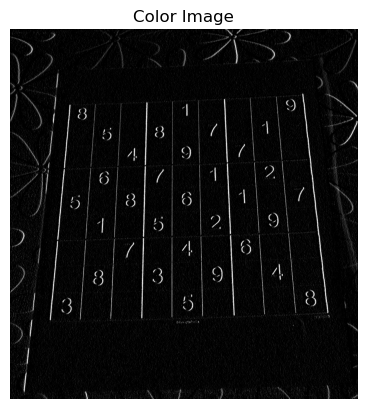

In [9]:
sudoku_sobel_x = cv2.Sobel(sudoku, ddepth=-1, dx=1, dy=0)

show(sudoku_sobel_x)

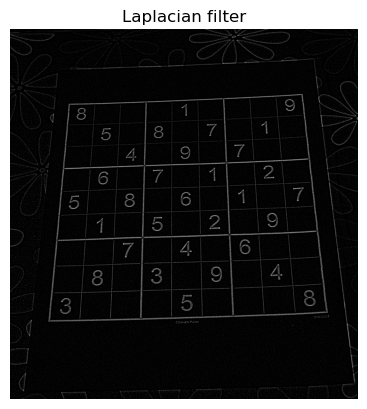

In [10]:
sudoku_gaussion = cv2.GaussianBlur(sudoku, (5, 5), 0)
sudoku_laplacian = cv2.Laplacian(sudoku_gaussion, ddepth=-1)
sudoku_laplacian = cv2.convertScaleAbs(sudoku_laplacian, dst=-1)

show(sudoku_laplacian, title="Laplacian filter")

### 🌀 Seamless cloning

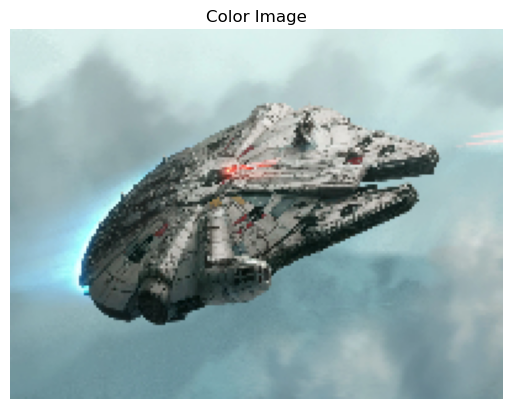

In [13]:
show(falcon)

In [23]:
mask_eye = np.zeros(shape=eye.shape[:2], dtype=np.uint8)

mask_eye[20:160, 50:160] = 255

center = (250, 250)

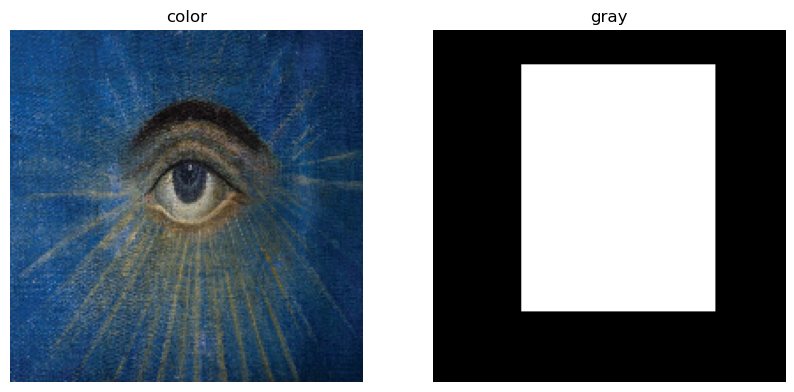

In [24]:
side2side(eye, mask_eye)

In [34]:
seamless_cloning_result_1 = cv2.seamlessClone(eye, pyramid, mask_eye, center, cv2.NORMAL_CLONE)

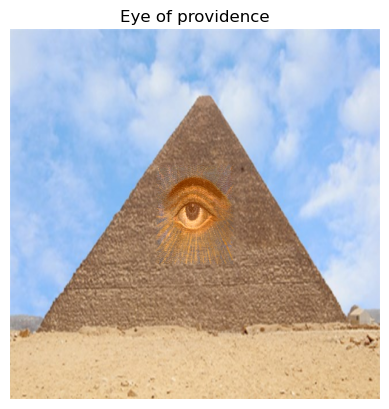

In [35]:
show(seamless_cloning_result_1, title="Eye of providence")

In [29]:
mask_falcon = np.zeros(shape=falcon.shape[:2], dtype=np.uint8)

points = np.array(
    [
        [97, 20],
        [35, 62],
        [5, 128],
        [113, 124],
        [172, 87],
        [192, 24]
    ]
)

mask_falcon = cv2.fillPoly(mask_falcon, [points], 255)

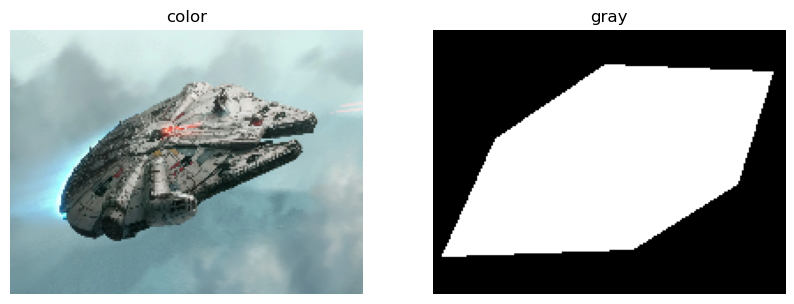

In [30]:
side2side(falcon, mask_falcon)

In [45]:
seamless_cloning_result_2 = cv2.seamlessClone(falcon, seamless_cloning_result_1, mask_falcon, (100, 75), cv2.NORMAL_CLONE)

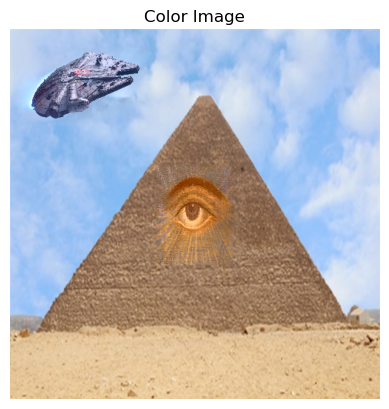

In [46]:
show(seamless_cloning_result_2)

In [48]:
store(seamless_cloning_result_2, output_path / "1.png")

### 🌀 Seamless cloning (cont.)

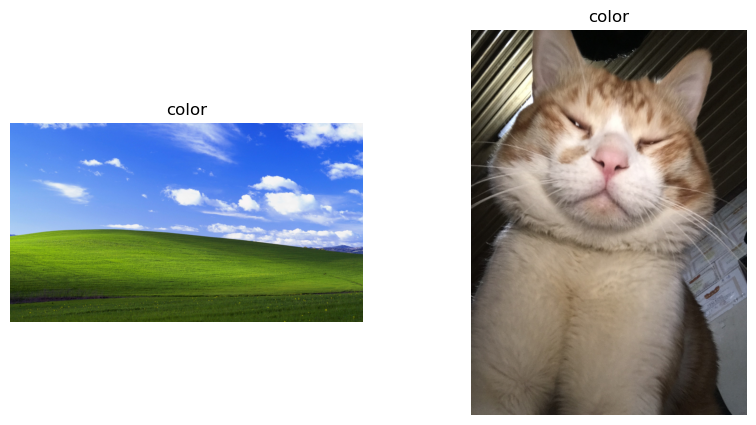

In [60]:
side2side(windowXp, my_cat)

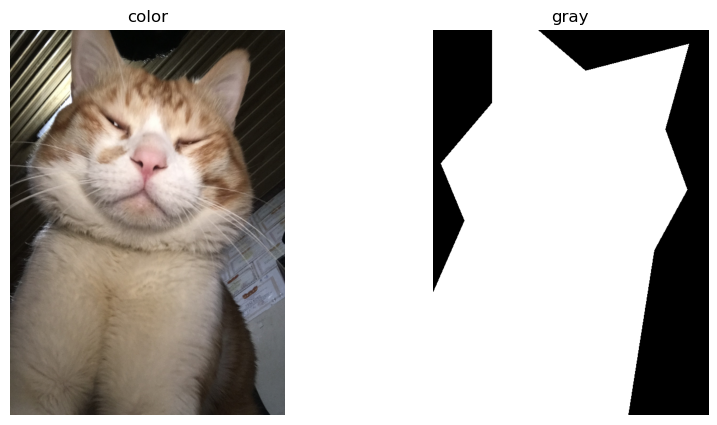

In [64]:
mask_cat = np.zeros(shape=my_cat.shape[:2], dtype=np.uint8)

points = np.array(
    [
        [107, 0],
        [107, 132],
        [14, 242],
        [57, 346],
        [0, 477],
        [0, 700],
        [353, 700],
        [400, 400],
        [460, 290],
        [420, 180],
        [463, 25],
        [276, 74],
        [190, 0]
    ]
)

mask_cat = cv2.fillPoly(img=mask_cat, pts=[points], color=255)

side2side(my_cat, mask_cat)

In [74]:
windowXo_my_cat = cv2.seamlessClone(src=my_cat, dst=windowXp, mask=mask_cat, p=(1400,350), flags=cv2.NORMAL_CLONE)

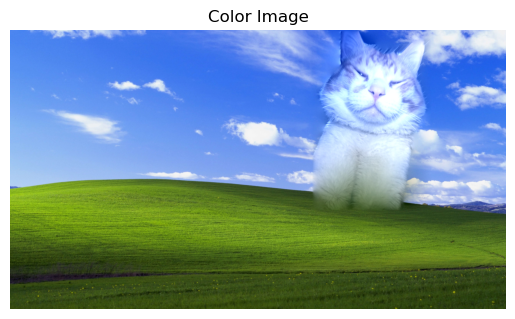

In [75]:
show(windowXo_my_cat)

In [77]:
store(windowXo_my_cat, output_path / "2.png")